## 0. Install Dependencies


In [22]:
!pip install -q easyocr ultralytics gdown


## 1. Train MRZ Zone Detector
Fine-tune YOLOv8n on MIDV-2020 passport subset (Azerbaijan, Greece, Serbia). 300 images, 50 epochs, Kaggle T4 GPU.

> **Note:** Training requires the MIDV-2020 dataset which cannot be redistributed per its licence. See README for download instructions. Cells 1–3 are documentation of the original training run and cannot be rerun without the dataset.

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/nightverify_mrz/dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    project="/content/nightverify_mrz",
    name="mrz_detector",
    plots=True  # this saves all the curves automatically
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/nightverify_mrz/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v

## 2. Training Curves
Loss, precision and mAP50 over epochs.

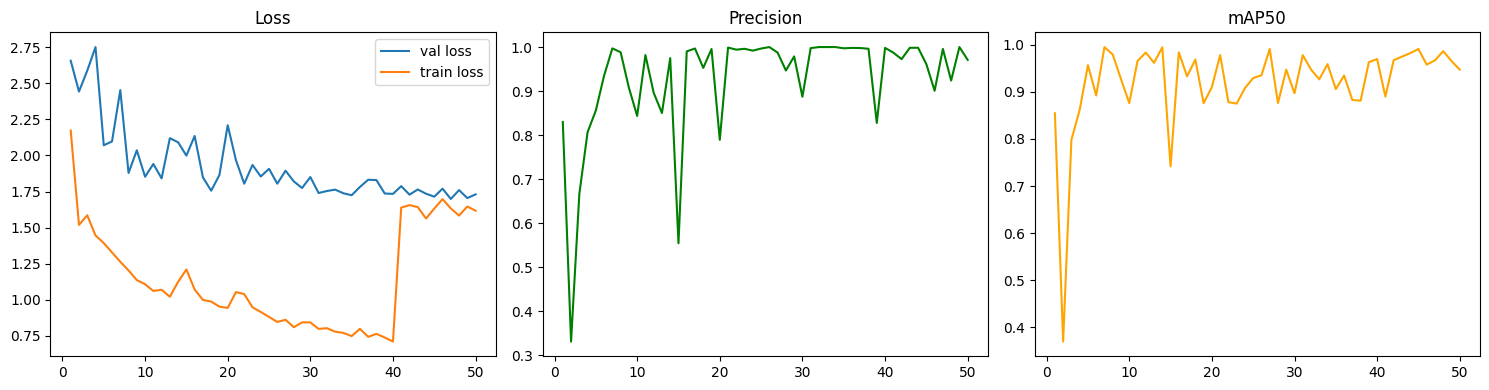

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/nightverify_mrz/mrz_detector/results.csv")
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df["epoch"], df["val/box_loss"], label="val loss")
axes[0].plot(df["epoch"], df["train/box_loss"], label="train loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(df["epoch"], df["metrics/precision(B)"], color="green")
axes[1].set_title("Precision")

axes[2].plot(df["epoch"], df["metrics/mAP50(B)"], color="orange")
axes[2].set_title("mAP50")

plt.tight_layout()
plt.show()

## 3. Training Metrics
Full per-epoch results.


In [ ]:
import pandas as pd

results_dir = "/kaggle/working/nightverify_mrz/mrz_detector"
df = pd.read_csv(f"{results_dir}/results.csv")
df.columns = df.columns.str.strip()
print(df[["epoch", "train/box_loss", "val/box_loss", "metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)"]].to_string())

    epoch  train/box_loss  val/box_loss  metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)
0       1         2.17311       2.65627               0.82999            0.70000           0.85449
1       2         1.51900       2.44260               0.33156            0.61250           0.37000
2       3         1.58569       2.58759               0.66641            0.83656           0.79810
3       4         1.44602       2.75096               0.80685            0.75000           0.86167
4       5         1.39350       2.07054               0.85611            0.88750           0.95668
5       6         1.32825       2.09766               0.93535            0.81250           0.89216
6       7         1.26350       2.45273               0.99704            1.00000           0.99500
7       8         1.20339       1.87876               0.98822            0.87500           0.97924
8       9         1.13708       2.03600               0.90763            0.91250           0.92708
9      10 

## 4. Inference Pipeline Definition
MRZ detection, OCR, numeric correction, and ICAO checksum validation.

In [11]:
%%writefile /kaggle/working/mrz_detector.py

from ultralytics import YOLO
import easyocr
import cv2
import numpy as np
from datetime import date

# load models
model = YOLO("/kaggle/working/best_mrz_v2.pt")
reader = easyocr.Reader(['en'])

def detect_mrz(img):
    results = model(img)[0]

    if len(results.boxes) == 0:
        return None

    boxes = results.boxes.xyxy.cpu().numpy().astype(int)
    areas = [(b[2] - b[0]) * (b[3] - b[1]) for b in boxes]
    best_box = boxes[int(np.argmax(areas))]

    MRZ_PADDING = 120  
    y1 = max(0, best_box[1] - MRZ_PADDING)
    y2 = min(img.shape[0], best_box[3] + MRZ_PADDING)
    mrz_crop = img[y1:y2, best_box[0]:best_box[2]]

    mrz_crop = cv2.resize(mrz_crop, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

    raw_lines = reader.readtext(
        mrz_crop,
        detail=0,
        allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789<",
    )

    mrz_lines = []
    for line in raw_lines:
        cleaned = line.upper().replace(" ", "")
     
        if len(cleaned) >= 20 and cleaned.count("<") >= 3:
            mrz_lines.append(cleaned)

    return mrz_lines if mrz_lines else None


def check_digit(field):
    weights = [7, 3, 1]
    values = {'<': 0}
    for i, c in enumerate('ABCDEFGHIJKLMNOPQRSTUVWXYZ'):
        values[c] = i + 10
    for i in range(10):
        values[str(i)] = i
    total = sum(values.get(c, 0) * weights[i % 3] for i, c in enumerate(field))
    return total % 10


def fix_numeric_fields(line2):
    digit_only_positions = [9, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27]
    char_to_digit = {'O': '0', 'I': '1', 'L': '1', 'S': '5', 'B': '8', 'G': '6', 'Z': '2'}
    chars = list(line2)
    for i in digit_only_positions:
        if i < len(chars) and chars[i] in char_to_digit:
            chars[i] = char_to_digit[chars[i]]
    return ''.join(chars)


def verify_passport(image_path, min_age=18):
    print(f"processing: {image_path}")
    img = cv2.imread(str(image_path))

    if img is None:
        print(f"could not load image: {image_path}")
        return

    mrz_lines = detect_mrz(img)

    if not mrz_lines:
        print("could not detect MRZ zone")
        return

    line2 = mrz_lines[-1]
    line2 = fix_numeric_fields(line2)

    if len(line2) < 20:
        print("MRZ line too short")
        return

    checks = {
        "document_number": (line2[0:9],   line2[9]),
        "date_of_birth":   (line2[13:19], line2[19]),
        "expiry_date":     (line2[21:27], line2[27]),
    }

    ocr_failures = []
    checksum_failures = []

    for field_name, (value, expected_char) in checks.items():
        if not expected_char.isdigit():
            ocr_failures.append(field_name)
        elif check_digit(value) != int(expected_char):
            checksum_failures.append(field_name)

    if checksum_failures:
        print(f"FAKE — checksum failed on {', '.join(checksum_failures)}")
        return False, f"checksum failed on {', '.join(checksum_failures)}"

    if ocr_failures:
        print(f"REAL (low confidence) — OCR uncertain on {', '.join(ocr_failures)}")
        return True, f"checksums passed where readable — OCR uncertain on {', '.join(ocr_failures)}"

    print("REAL — all checks passed")
    return True, "all checks passed"

Overwriting /content/mrz_detector.py


## 5. Demo — Run Inference on Test Image

Runs the full MRZ verification pipeline on a MIDV-2020 passport image.

> **Note:** Test image is a MIDV-2020 synthetic template scan. EasyOCR accuracy on synthetic 
> renders is lower than on real passport photos. This is a documented limitation.
> The pipeline correctly detects both MRZ zones in all cases.
>Test image is from MIDV-2020 which cannot be redistributed per its licence.
>  To rerun this cell, download MIDV-2020, locate any passport image from the `aze_passport` or
> `grc_passport` subset, and update the `IMAGE` path accordingly.

Downloading...
From: https://drive.google.com/uc?id=1z_Hw4CfMyudnp1ZxfHCjUaQek_hpcGfF
To: /kaggle/working/best_mrz_v2.pt
100%|██████████| 6.23M/6.23M [00:00<00:00, 62.6MB/s]
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


image size: (803, 1136, 3)

image 1/1 /kaggle/input/datasets/giorgiamerli/fakeid-mrz-weights/08.jpg: 480x640 2 mrzs, 109.8ms
Speed: 4.5ms preprocess, 109.8ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)
detections: 2


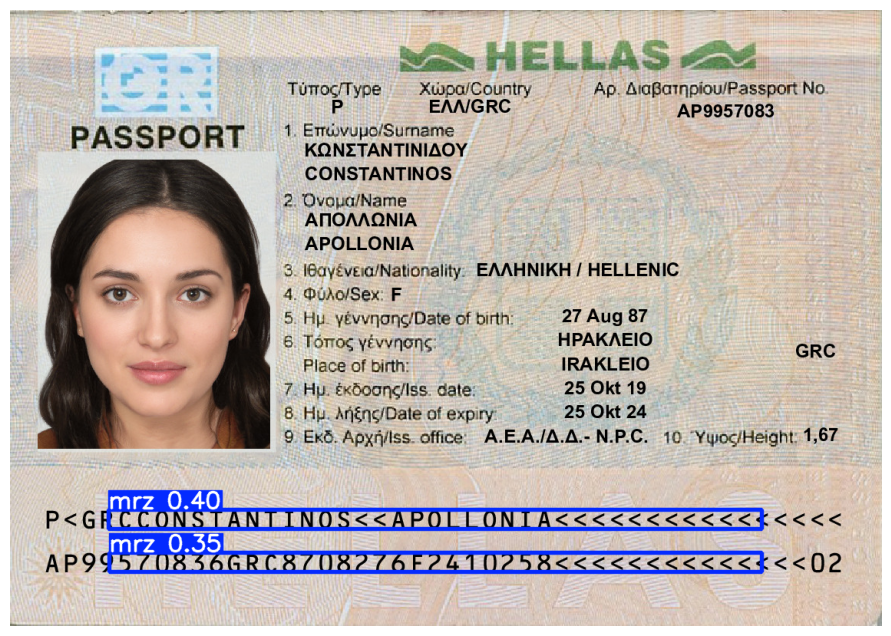

processing: /kaggle/input/datasets/giorgiamerli/fakeid-mrz-weights/08.jpg

0: 480x640 2 mrzs, 104.3ms
Speed: 3.2ms preprocess, 104.3ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)
FAKE — checksum failed on document_number, date_of_birth


In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import easyocr

# weights downloaded from Google Drive — see README for link
import gdown
gdown.download("https://drive.google.com/uc?id=1z_Hw4CfMyudnp1ZxfHCjUaQek_hpcGfF", "/kaggle/working/best_mrz_v2.pt", quiet=False)
WEIGHTS = "/kaggle/working/best_mrz_v2.pt"
IMAGE = "/kaggle/input/datasets/giorgiamerli/fakeid-mrz-weights/08.jpg"

mrz_model = YOLO(WEIGHTS)
mrz_reader = easyocr.Reader(['en'])

def detect_mrz(img):
    results = mrz_model(img)[0]
    if len(results.boxes) == 0:
        return None
    boxes = results.boxes.xyxy.cpu().numpy().astype(int)
    areas = [(b[2]-b[0])*(b[3]-b[1]) for b in boxes]
    best_box = boxes[int(np.argmax(areas))]
    MRZ_PADDING = 120
    y1 = max(0, best_box[1] - MRZ_PADDING)
    y2 = min(img.shape[0], best_box[3] + MRZ_PADDING)
    mrz_crop = img[y1:y2, best_box[0]:best_box[2]]
    mrz_crop = cv2.resize(mrz_crop, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    raw_lines = mrz_reader.readtext(mrz_crop, detail=0, allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789<")
    mrz_lines = []
    for line in raw_lines:
        cleaned = line.upper().replace(" ", "")
        if len(cleaned) >= 20 and cleaned.count("<") >= 3:
            mrz_lines.append(cleaned)
    return mrz_lines if mrz_lines else None

def check_digit(field):
    weights = [7, 3, 1]
    values = {'<': 0}
    for i, c in enumerate('ABCDEFGHIJKLMNOPQRSTUVWXYZ'):
        values[c] = i + 10
    for i in range(10):
        values[str(i)] = i
    return sum(values.get(c, 0) * weights[i % 3] for i, c in enumerate(field)) % 10

def fix_numeric_fields(line2):
    digit_only_positions = [9,13,14,15,16,17,18,19,21,22,23,24,25,26,27]
    char_to_digit = {'O':'0','I':'1','L':'1','S':'5','B':'8','G':'6','Z':'2'}
    chars = list(line2)
    for i in digit_only_positions:
        if i < len(chars) and chars[i] in char_to_digit:
            chars[i] = char_to_digit[chars[i]]
    return ''.join(chars)

def verify_passport(image_path):
    print(f"processing: {image_path}")
    img = cv2.imread(str(image_path))
    if img is None:
        print("could not load image")
        return
    mrz_lines = detect_mrz(img)
    if not mrz_lines:
        print("could not detect MRZ zone")
        return
    line2 = fix_numeric_fields(mrz_lines[-1])
    if len(line2) < 20:
        print("MRZ line too short")
        return
    checks = {
        "document_number": (line2[0:9], line2[9]),
        "date_of_birth":   (line2[13:19], line2[19]),
        "expiry_date":     (line2[21:27], line2[27]),
    }
    ocr_failures = []
    checksum_failures = []
    for field_name, (value, expected_char) in checks.items():
        if not expected_char.isdigit():
            ocr_failures.append(field_name)
        elif check_digit(value) != int(expected_char):
            checksum_failures.append(field_name)
    if checksum_failures:
        print(f"FAKE — checksum failed on {', '.join(checksum_failures)}")
        return
    if ocr_failures:
        print(f"REAL (low confidence) — OCR uncertain on {', '.join(ocr_failures)}")
        return
    print("REAL — all checks passed")

# show YOLO detection
img = cv2.imread(IMAGE)
print(f"image size: {img.shape}")
results = mrz_model(IMAGE)[0]
print(f"detections: {len(results.boxes)}")
annotated = results.plot()
plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# run full verification
verify_passport(IMAGE)